In [50]:
#Biblioteca de manipulação dos dados
import pandas as  pd
from sklearn.impute import SimpleImputer
from scipy.stats.mstats import winsorize
import numpy as np
from sklearn.pipeline import Pipeline

#Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

#importação dos modulos
import sys
%load_ext autoreload
%autoreload 2
sys.path.append('../Utils')

#separar os dados em treino e teste
from sklearn.model_selection import train_test_split

#Uteis
from Uteis import TratamentoDados, Graficos

#Filtra warnings
import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [51]:
utilTratamento = TratamentoDados()
utilGraficos = Graficos()

In [4]:
df = pd.read_csv("../Dados/credit_train.csv")
df.head()

,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,14dd8831-6af5-400b-83ec-68e61888a048,981165ec-3274-42f5-a3b4-d104041a9ca9,Fully Paid,445412.0,Short Term,709.0,1167493.0,8 years,Home Mortgage,Home Improvements,5214.74,17.2,NaN,6.0,1.0,228190.0,416746.0,1.0,0.0
1,4771cc26-131a-45db-b5aa-537ea4ba5342,2de017a3-2e01-49cb-a581-08169e83be29,Fully Paid,262328.0,Short Term,NaN,NaN,10+ years,Home Mortgage,Debt Consolidation,33295.98,21.1,8.0,35.0,0.0,229976.0,850784.0,0.0,0.0
2,4eed4e6a-aa2f-4c91-8651-ce984ee8fb26,5efb2b2b-bf11-4dfd-a572-3761a2694725,Fully Paid,99999999.0,Short Term,741.0,2231892.0,8 years,Own Home,Debt Consolidation,29200.53,14.9,29.0,18.0,1.0,297996.0,750090.0,0.0,0.0
3,77598f7b-32e7-4e3b-a6e5-06ba0d98fe8a,e777faab-98ae-45af-9a86-7ce5b33b1011,Fully Paid,347666.0,Long Term,721.0,806949.0,3 years,Own Home,Debt Consolidation,8741.90,12.0,NaN,9.0,0.0,256329.0,386958.0,0.0,0.0
4,d4062e70-befa-4995-8643-a0de73938182,81536ad9-5ccf-4eb8-befb-47a4d608658e,Fully Paid,176220.0,Short Term,NaN,NaN,5 years,Rent,Debt Consolidation,20639.70,6.1,NaN,15.0,0.0,253460.0,427174.0,0.0,0.0


In [5]:
df.describe()

,Current Loan Amount,Credit Score,Annual Income,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
count,1.000000e+05,80846.000000,8.084600e+04,100000.000000,100000.000000,46859.000000,100000.00000,100000.000000,1.000000e+05,9.999800e+04,99796.000000,99990.000000
mean,1.176045e+07,1076.456089,1.378277e+06,18472.412336,18.199141,34.901321,11.12853,0.168310,2.946374e+05,7.607984e+05,0.117740,0.029313
std,3.178394e+07,1475.403791,1.081360e+06,12174.992609,7.015324,21.997829,5.00987,0.482705,3.761709e+05,8.384503e+06,0.351424,0.258182
min,1.080200e+04,585.000000,7.662700e+04,0.000000,3.600000,0.000000,0.00000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,1.796520e+05,705.000000,8.488440e+05,10214.162500,13.500000,16.000000,8.00000,0.000000,1.126700e+05,2.734380e+05,0.000000,0.000000
50%,3.122460e+05,724.000000,1.174162e+06,16220.300000,16.900000,32.000000,10.00000,0.000000,2.098170e+05,4.678740e+05,0.000000,0.000000
75%,5.249420e+05,741.000000,1.650663e+06,24012.057500,21.700000,51.000000,14.00000,0.000000,3.679588e+05,7.829580e+05,0.000000,0.000000
max,1.000000e+08,7510.000000,1.655574e+08,435843.280000,70.500000,176.000000,76.00000,15.000000,3.287897e+07,1.539738e+09,7.000000,15.000000


Agora irei analisar se há valores faltantes. Entretanto, já observei um valor exorbitante de 99999999.0 na variável current score, o que pode ser um indicativo claro de outliers. Tratarei desses casos logo após o tratamento dos valores ausentes.
Mas antes, vou separar os dados em treino e teste — desde que não haja valores vazios na coluna Loan Status, pois essa coluna é essencial para a separação estratificada. Todo e qualquer tratamento que eu fizer no treino será replicado no teste.

In [6]:
df.isna().sum()

Loan ID                           514
Customer ID                       514
Loan Status                       514
Current Loan Amount               514
Term                              514
Credit Score                    19668
Annual Income                   19668
Years in current job             4736
Home Ownership                    514
Purpose                           514
Monthly Debt                      514
Years of Credit History           514
Months since last delinquent    53655
Number of Open Accounts           514
Number of Credit Problems         514
Current Credit Balance            514
Maximum Open Credit               516
Bankruptcies                      718
Tax Liens                         524
dtype: int64

A base de dados apresenta muitos valores faltantes, sendo 514 deles um padrão em quase todas as colunas. Isso pode indicar uma relação entre esses valores ausentes. Para investigar isso mais de perto, pretendo filtrar os valores faltantes e verificar se há algum padrão ou se são apenas valores aleatoriamente ausentes.

In [7]:
dfFaltantes = df[df["Loan ID"].isna() == True]
dfFaltantes


,Loan ID,Customer ID,Loan Status,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
100000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100509,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
100512,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Como previsto, os valores faltantes correspondem a linhas completamente vazias, evidenciando um padrão claro. Diante disso, irei remover essas linhas ausentes da base de dados para prosseguir com a análise.

In [8]:
dfFaltantes2 = df[~df["Loan ID"].isna() == True]
dfFaltantes2.isna().sum()

Loan ID                             0
Customer ID                         0
Loan Status                         0
Current Loan Amount                 0
Term                                0
Credit Score                    19154
Annual Income                   19154
Years in current job             4222
Home Ownership                      0
Purpose                             0
Monthly Debt                        0
Years of Credit History             0
Months since last delinquent    53141
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
Maximum Open Credit                 2
Bankruptcies                      204
Tax Liens                          10
dtype: int64

Após a remoção, vemos que o pradrão dos valores faltantes retirado da base de dados, agora analisarei esses valores de Credit Score e Annual Income que apresentam valores faltantes iguais. Mas antes irei analisar se há duplicatas

In [9]:
dfFaltantes2.duplicated().sum()

10215

Na base de dados, identifiquei um total de 10.215 amostras duplicadas, o que representa uma quantidade significativa e pode impactar negativamente a qualidade do modelo. Para entender melhor, realizei uma investigação para identificar quem são esses clientes com registros duplicados.

In [10]:
duplicatas = dfFaltantes2[dfFaltantes2.duplicated(keep=False)]
duplicatas["Loan Status"].value_counts()


Loan Status
Fully Paid    20430
Name: count, dtype: int64

Como todas as duplicatas pertencem à classe Fully Paid (pagamento efetuado), não há conflito ou ambiguidade na variável alvo nesses registros repetidos. Portanto, esses dados não trazem informação nova para o modelo e podem ser removidos sem impacto negativo no desempenho ou viés do modelo. Isso ajuda a reduzir o tamanho da base e melhora a qualidade dos dados para a modelagem.

In [11]:
dfFaltantes2.drop_duplicates(inplace=True)
dfFaltantes2.duplicated().sum()

C:\Users\rianf\AppData\Local\Temp\ipykernel_7448\3038037306.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfFaltantes2.drop_duplicates(inplace=True)


0


Feita a remoção dessas duplicatas, posso separar os dados em treino e teste para continuar minha análise dos valores faltantes.

In [12]:
train_df, test_df = train_test_split(dfFaltantes2, test_size=0.2, random_state=42, stratify=dfFaltantes2['Loan Status'])

In [13]:
train_df.isna().sum()

Loan ID                             0
Customer ID                         0
Loan Status                         0
Current Loan Amount                 0
Term                                0
Credit Score                    15362
Annual Income                   15362
Years in current job             3056
Home Ownership                      0
Purpose                             0
Monthly Debt                        0
Years of Credit History             0
Months since last delinquent    38704
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
Maximum Open Credit                 0
Bankruptcies                      145
Tax Liens                           5
dtype: int64

Para prosseguir na investigação de Credit Score e Annual Income, é necessário analisar se existe alguma relação com a variável target (Loan Status). Caso eu simplesmente preencha os valores faltantes com a média ou mediana, posso acabar eliminando uma possível correlação. Portanto, antes disso, irei verificar se há alguma diferença nessas duas variáveis em relação à target.

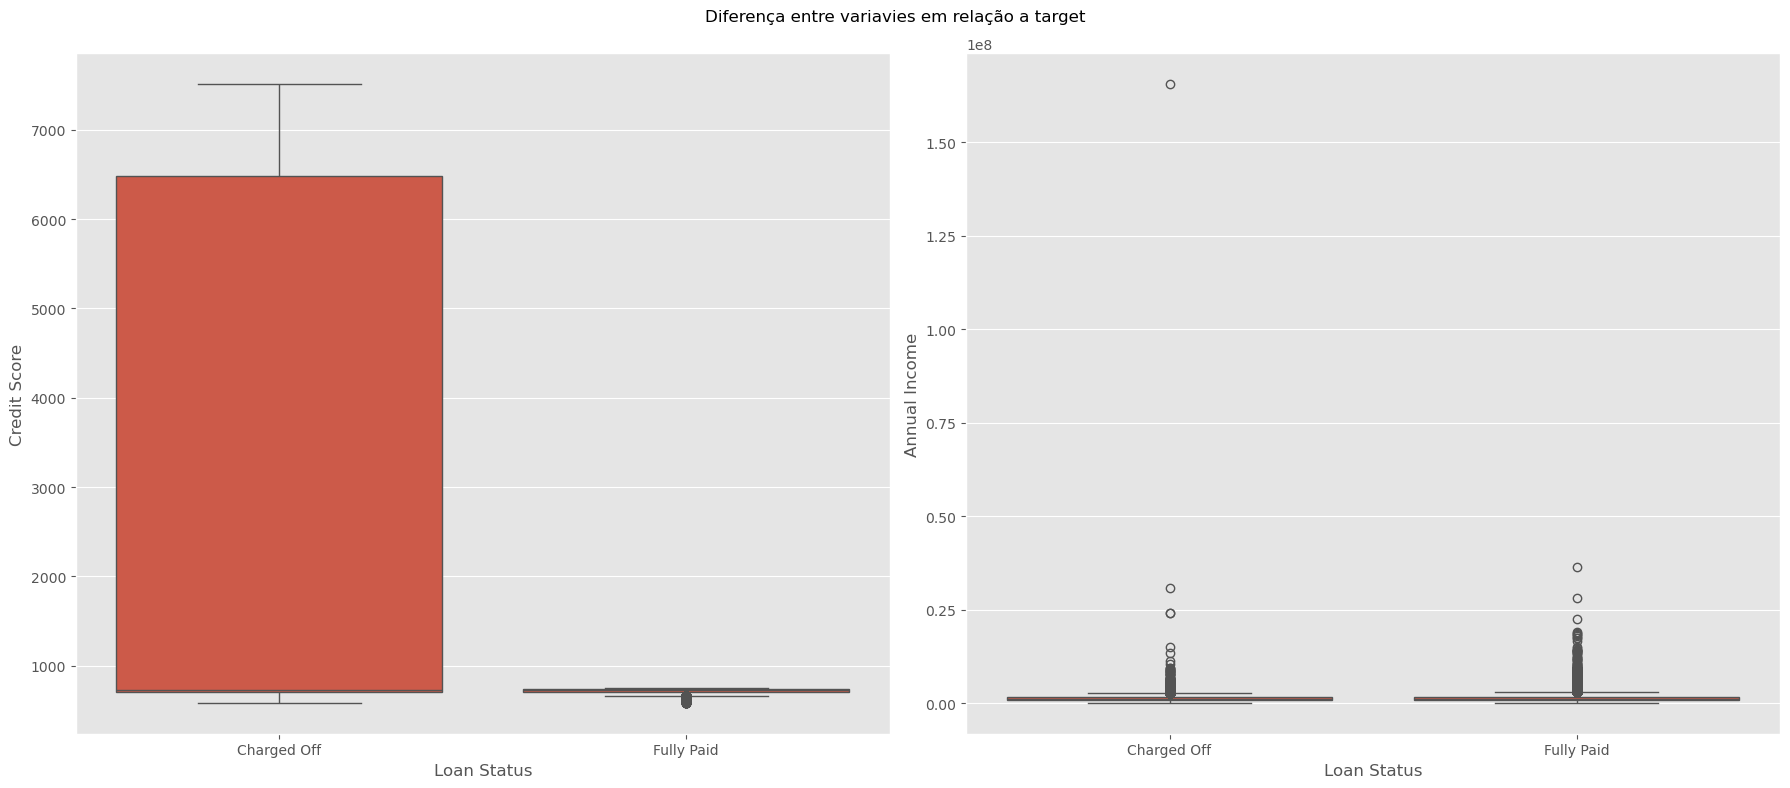

In [14]:
utilGraficos.relacaoDeVariaveisComTargetBoxplot(train_df, ["Credit Score", "Annual Income"], 2, 1)



Após a análise dos gráficos, duas conclusões principais se destacam:

1. Existe uma correlação entre o Credit Score e a variável target (Loan Status). Observa-se que clientes que normalmente não quitam seus empréstimos apresentam scores elevados, o que é um comportamento um tanto contraintuitivo. Uma possível hipótese é que esses clientes, em algum momento, consigam elevar seu score e aproveitem para realizar gastos elevados, mas posteriormente não disponham dos recursos necessários para pagar. Contudo, essa suposição não pode ser confirmada, já que não há como contatar esses clientes para um entendimento mais aprofundado. Para evitar enviesar o modelo, optei por utilizar a **mediana** para imputar os valores faltantes. Isso porque, apesar de a classe minoritária apresentar médias mais altas, seus valores variam desde os mais baixos até os mais elevados, e a mediana é menos influenciada por extremos e por diferenças de proporção entre as classes. Dessa forma, o preenchimento se mantém mais neutro e representativo.

2. Não há uma correlação significativa entre a variável Annual Income e a target. Contudo, essa variável apresenta um outlier muito expressivo, o qual pode prejudicar o desempenho do modelo final. Por esse motivo, optei por tratar esse outlier por meio de winzorization mas antes vou preencher com a mediana.


In [15]:
#Vai ser utilizado para preencher os valores vazios com base na mediana
imputar_mediana_credit = SimpleImputer(strategy="median")  
imputar_mediana_annual_income = SimpleImputer(strategy="median")

#Aplicando a mediana no treino e no teste
train_df["Credit Score"] = imputar_mediana_credit.fit_transform(train_df[["Credit Score"]])
test_df["Credit Score"] = imputar_mediana_credit.transform(test_df[["Credit Score"]])

train_df["Annual Income"] = imputar_mediana_annual_income.fit_transform(train_df[["Annual Income"]])
test_df["Annual Income"] = imputar_mediana_annual_income.transform(test_df[["Annual Income"]])


In [16]:
print(train_df.isna().sum())

Loan ID                             0
Customer ID                         0
Loan Status                         0
Current Loan Amount                 0
Term                                0
Credit Score                        0
Annual Income                       0
Years in current job             3056
Home Ownership                      0
Purpose                             0
Monthly Debt                        0
Years of Credit History             0
Months since last delinquent    38704
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
Maximum Open Credit                 0
Bankruptcies                      145
Tax Liens                           5
dtype: int64


Agora irei remover o outlier de Annual Income

In [17]:
np.max(train_df["Annual Income"])

165557393.0

In [18]:
np.max(test_df["Annual Income"])

22448880.0

Durante a análise exploratória, identifiquei que a variável Annual Income apresenta um valor extremamente alto no conjunto de treino (≈165,5 milhões) e outro também elevado no conjunto de teste (≈22,4 milhões). Considerando que, de acordo com o describe(), até o terceiro quartil os valores chegam apenas a cerca de 1,65 milhão, esses máximos representam pontos extremos que destoam fortemente da distribuição.

Manter tais valores poderia enviesar o modelo, principalmente em algoritmos sensíveis a escala e dispersão. Por esse motivo, optei por aplicar winsorization utilizando limites calculados a partir do conjunto de treino, de forma a substituir esses extremos por um valor máximo plausível. Essa abordagem reduz o impacto desses outliers sem removê-los completamente, preservando a variabilidade natural da variável.

In [19]:
train_df = utilTratamento.aplicarWinsorizacao(train_df, ["Annual Income"])
test_df = utilTratamento.aplicarWinsorizacao(test_df, ["Annual Income"])

np.max(train_df["Annual Income"])

4201337.0

In [20]:
np.max(test_df["Annual Income"])

4189500.0

Após o tratamento dos dados, com a redução do impacto do outlier extremo, conseguimos manter um padrão consistente entre os conjuntos de treino e teste. Dessa forma, não há risco de enviesamento nos dados nem diferenças significativas entre os conjuntos:

Valor máximo no treino: 4.201.337

Valor máximo no teste: 4.189.500

Isso garante que o modelo seja treinado e avaliado em distribuições semelhantes, aumentando a confiabilidade dos resultados. Agora irei analisar os dados do Years in current job já que apresenta uma alguns outliers

In [21]:
train_df[train_df["Years in current job"].isna() == True]["Loan Status"].value_counts()

Loan Status
Fully Paid     2029
Charged Off    1027
Name: count, dtype: int64

Após a análise dos valores faltantes, percebi que eles não estão associados a nenhuma classe específica. Como representam apenas 4% dos dados totais (3056 de 71828 registros), tratarei esses valores da seguinte forma:
1. Para valores no formato "*n* números de anos + years", extrairei apenas o número do ano.
2. Para valores como "*+10 years*", manterei apenas o número 10.
3. Para valores como "*<0 years*", substituirei por 0.
4. Para campos vazios, utilizarei a mediana para preenchê-los.

Essa abordagem facilitará o pré-processamento, evitando complicações desnecessárias na base de dados, como a criação de colunas adicionais para codificação (*encoding*).

Em seguida, analisarei a coluna *Months since last delinquent* (número de meses desde a última inadimplência registrada), que apresenta uma quantidade significativa de valores vazios, cerca de 52%. Verificarei se esses valores ausentes correspondem a clientes que nunca tiveram inadimplências (ou seja, sempre pagaram seus empréstimos) ou se são aleatórios.

Após a análise, constatei que os valores faltantes não apresentam um padrão claro, o que me indica que posso preencher os valores vazios com a mediana.

In [22]:
#Aqui irá só tratar os dados categoricos em dados numéricos
train_df["Years in current job"] = train_df["Years in current job"].apply(utilTratamento.tratamentoValoresAnosTrabalhoAtual)
test_df["Years in current job"] = test_df["Years in current job"].apply(utilTratamento.tratamentoValoresAnosTrabalhoAtual)

#adicionando a mediana nos valores faltantes
imputar_mediana_years_in_current_job = SimpleImputer(strategy="median")
train_df["Years in current job"] = imputar_mediana_annual_income.fit_transform(train_df[["Years in current job"]])
test_df["Years in current job"] = imputar_mediana_annual_income.transform(test_df[["Years in current job"]])

In [23]:
train_df.isna().sum()

Loan ID                             0
Customer ID                         0
Loan Status                         0
Current Loan Amount                 0
Term                                0
Credit Score                        0
Annual Income                       0
Years in current job                0
Home Ownership                      0
Purpose                             0
Monthly Debt                        0
Years of Credit History             0
Months since last delinquent    38704
Number of Open Accounts             0
Number of Credit Problems           0
Current Credit Balance              0
Maximum Open Credit                 0
Bankruptcies                      145
Tax Liens                           5
dtype: int64

Agora Vamos analisar o Months since last delinquent, como ele apresenta uma quantidade muito grande de valores faltantes, irei analisar se ele apresenta algum padrão com a target(Loan Status), pois se não houver nenhuma relação irei apagar essa coluna

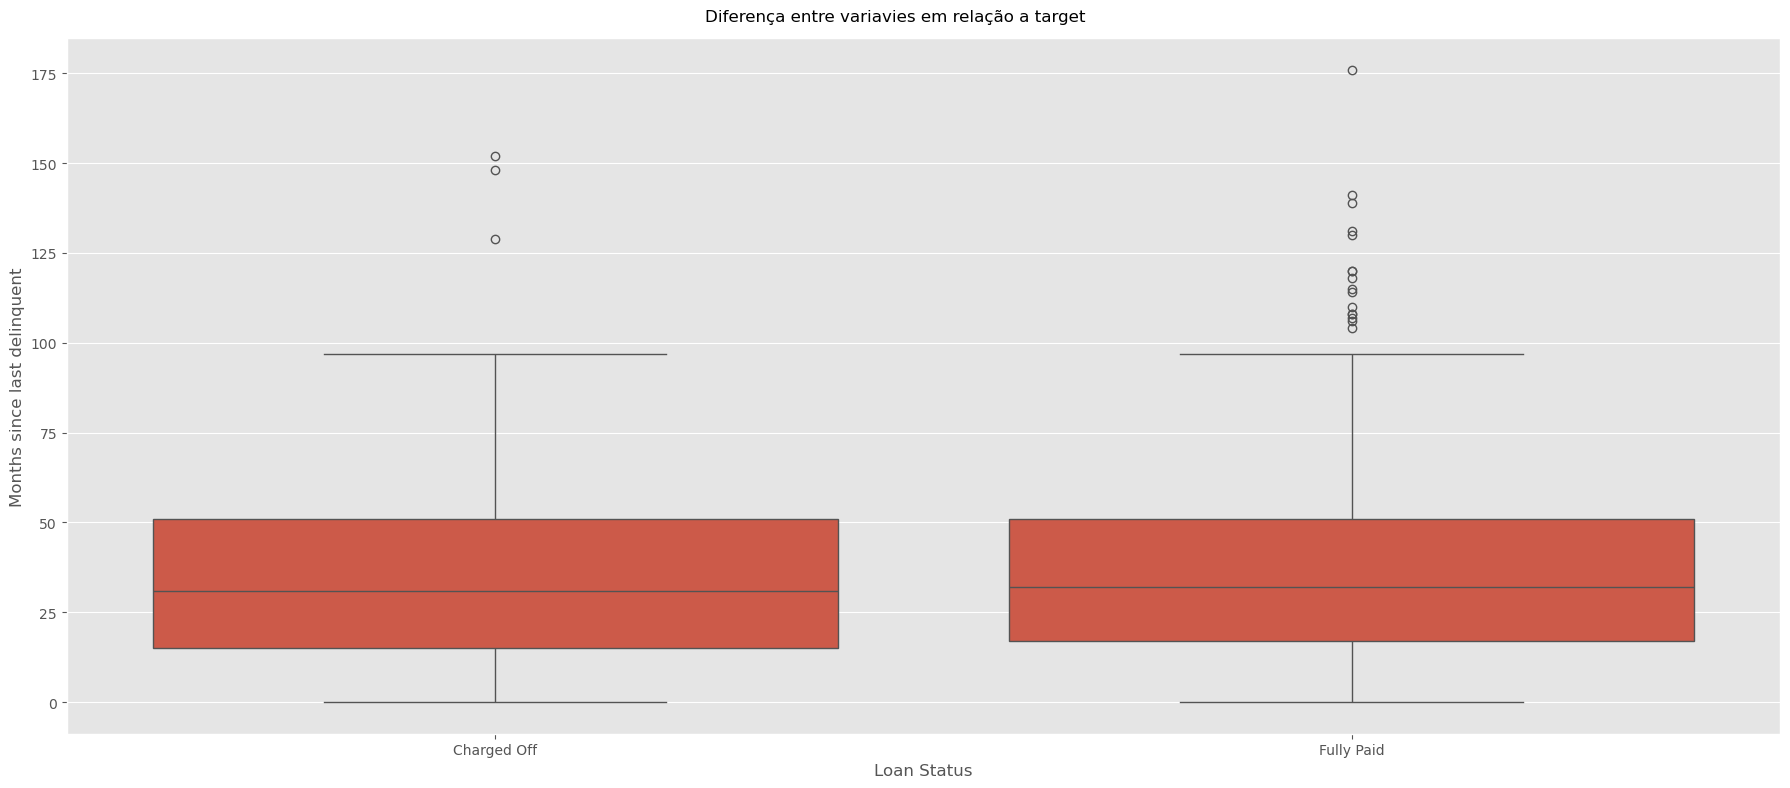

In [24]:
utilGraficos.relacaoDeVariaveisComTargetBoxplot(train_df, ["Months since last delinquent"], 1, 1)

Com base no gráfico, essa coluna não apresenta uma diferença clara em relação à variável target. Portanto, para simplificar o pré-processamento e evitar trabalhos desnecessários de imputação, irei simplesmente removê-la dos conjuntos de treino e teste.


In [25]:
train_df = train_df.drop("Months since last delinquent", axis = 1).copy()
test_df = test_df.drop("Months since last delinquent", axis = 1).copy()

In [26]:

train_df.isna().sum()


Loan ID                        0
Customer ID                    0
Loan Status                    0
Current Loan Amount            0
Term                           0
Credit Score                   0
Annual Income                  0
Years in current job           0
Home Ownership                 0
Purpose                        0
Monthly Debt                   0
Years of Credit History        0
Number of Open Accounts        0
Number of Credit Problems      0
Current Credit Balance         0
Maximum Open Credit            0
Bankruptcies                 145
Tax Liens                      5
dtype: int64

In [27]:
test_df.isna().sum()

Loan ID                       0
Customer ID                   0
Loan Status                   0
Current Loan Amount           0
Term                          0
Credit Score                  0
Annual Income                 0
Years in current job          0
Home Ownership                0
Purpose                       0
Monthly Debt                  0
Years of Credit History       0
Number of Open Accounts       0
Number of Credit Problems     0
Current Credit Balance        0
Maximum Open Credit           2
Bankruptcies                 45
Tax Liens                     4
dtype: int64

Ainda restam alguns valores faltantes, mas sua quantidade é muito pequena. Por isso, posso simplesmente substituí-los pela mediana, já que essa substituição não afetará a análise

In [28]:
# Colunas que você quer imputar
colunas_numericas = ['Maximum Open Credit', 'Bankruptcies', 'Tax Liens']

# Criar pipeline
pipeline_numericas = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Aplicar fit_transform apenas nessas colunas
train_df[colunas_numericas] = pipeline_numericas.fit_transform(train_df[colunas_numericas])
test_df[colunas_numericas] = pipeline_numericas.transform(test_df[colunas_numericas])

In [29]:
train_df.isna().sum()

Loan ID                      0
Customer ID                  0
Loan Status                  0
Current Loan Amount          0
Term                         0
Credit Score                 0
Annual Income                0
Years in current job         0
Home Ownership               0
Purpose                      0
Monthly Debt                 0
Years of Credit History      0
Number of Open Accounts      0
Number of Credit Problems    0
Current Credit Balance       0
Maximum Open Credit          0
Bankruptcies                 0
Tax Liens                    0
dtype: int64

In [30]:
test_df.isna().sum()

Loan ID                      0
Customer ID                  0
Loan Status                  0
Current Loan Amount          0
Term                         0
Credit Score                 0
Annual Income                0
Years in current job         0
Home Ownership               0
Purpose                      0
Monthly Debt                 0
Years of Credit History      0
Number of Open Accounts      0
Number of Credit Problems    0
Current Credit Balance       0
Maximum Open Credit          0
Bankruptcies                 0
Tax Liens                    0
dtype: int64

Agora, com a base de dados com todos os valores preenchidos, irei iniciar a análise exploratória. Antes disso, vou remover um outlier que identifiquei da coluna Current Loan Amount, que possui o valor 99.999.999,0, o qual claramente indica um erro.

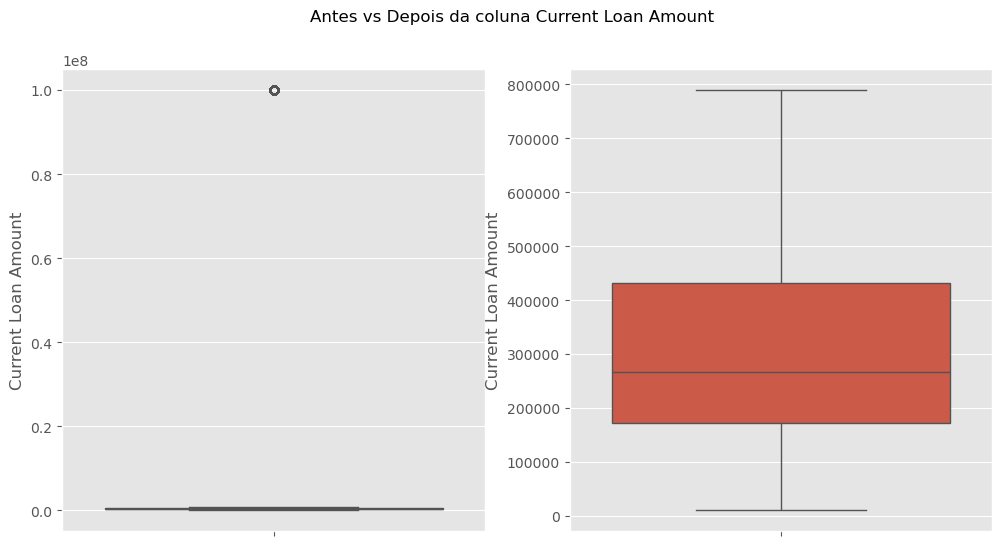

In [31]:
fig, axs = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)

dados_sem_outlier = train_df[train_df['Current Loan Amount'] < 99999999.0]["Current Loan Amount"]
dados_com_outiler = train_df['Current Loan Amount']
sns.boxplot(dados_com_outiler, ax = axs[0])
sns.boxplot(dados_sem_outlier, ax = axs[1])
plt.suptitle("Antes vs Depois da coluna Current Loan Amount")
plt.tight_layout
plt.show()


Fica evidente que esses outliers estavam distorcendo de forma exagerada a proporção dos dados. Portanto, irei removê-los para não prejudicar a análise exploratória nem comprometer o desempenho do modelo futuramente.

In [32]:
train_df = train_df[train_df['Current Loan Amount'] < 99999999.0]
test_df = test_df[test_df['Current Loan Amount'] < 99999999.0]


## Análise Exploratória de Dados (EDA)

Com a etapa de **tratamento de missing values** e **outliers** concluída, passamos agora para a **análise exploratória de dados (EDA)**.

O objetivo da EDA é compreender melhor o comportamento das variáveis, identificar padrões, relações e potenciais problemas nos dados. A análise exploratória pode ser dividida em três categorias principais:

1. **Univariada**
   Análise de cada variável individualmente, verificando distribuição, medidas de tendência central, dispersão, presença de outliers, entre outros aspectos.

2. **Bivariada**
   Estudo da relação entre duas variáveis, utilizando técnicas como correlações, tabelas cruzadas e gráficos de dispersão.

3. **Multivariada**
   Investigação envolvendo três ou mais variáveis simultaneamente, identificando interações complexas e padrões combinados, frequentemente utilizando visualizações como pairplots e heatmaps de correlação.

Antes de inicar a analise irei retirar as colunas Loan ID e Customer ID que de nada vão me servir na análise.




In [33]:
train_df.drop(columns = ["Loan ID", "Customer ID"], axis =1, inplace = True)
test_df.drop(columns = ["Loan ID", "Customer ID"], axis =1, inplace = True)

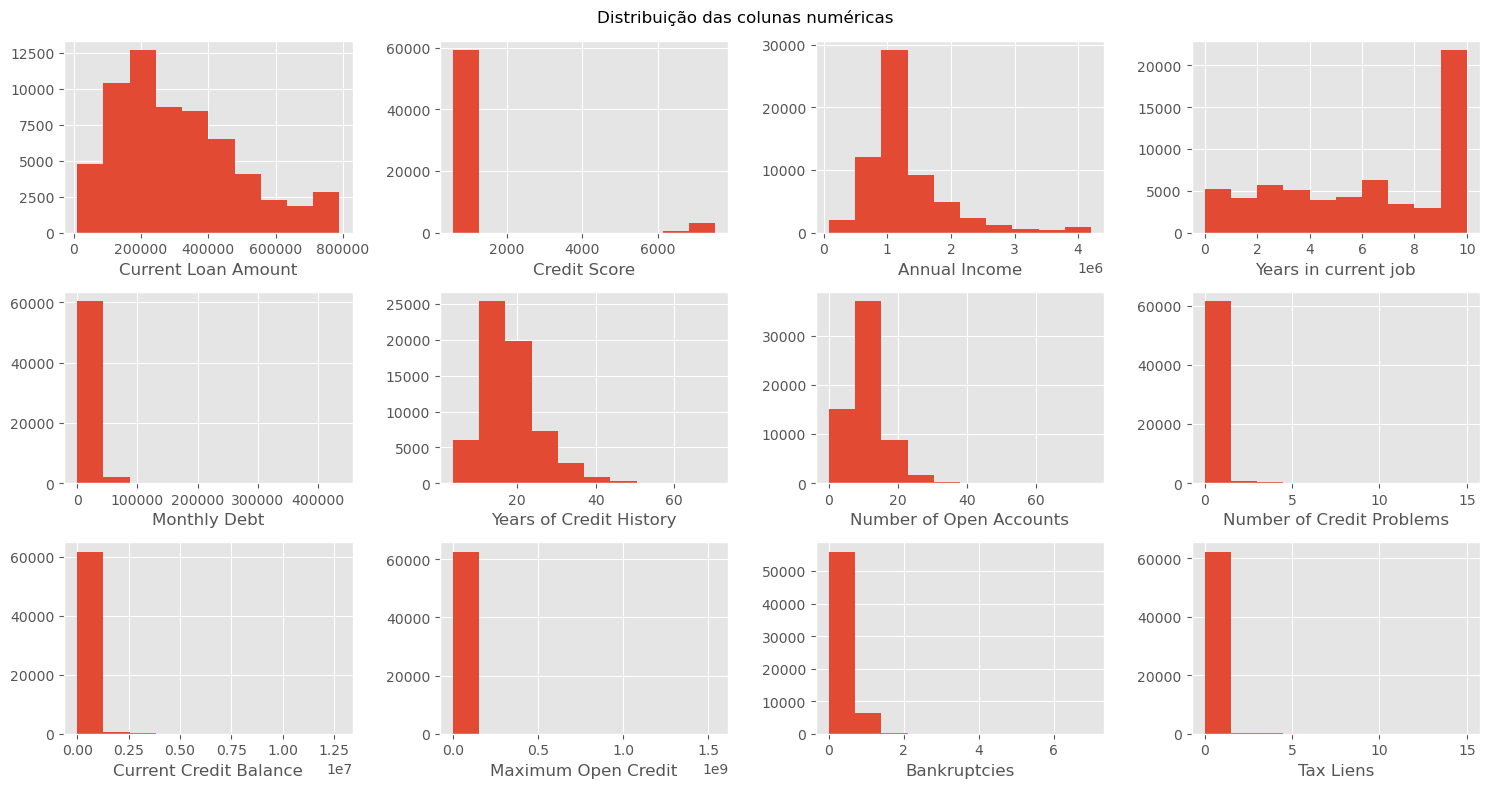

In [34]:
utilGraficos.analiseUnivariada(train_df, "number")

### Analises

1. **Credit Score**

   * A maior parte dos valores se concentra até pouco acima de **1.000 pontos**.
   * Entretanto, existem **outliers bem marcados**, o que já havia sido observado como uma característica clara de clientes inadimplentes.

2. **Years in Current Job**

   * Muitos clientes apresentam **mais de 10 anos no emprego atual**, o que sugere um perfil de clientes com **histórico profissional mais estável**.
   * Essa variável pode ser relevante para o modelo, pois estabilidade no emprego tende a estar relacionada a menor risco de inadimplência.

3. **Monthly Debt**

   * Foi identificado um **outlier extremamente alto**, possivelmente um único registro discrepante.
   * Esse ponto pode distorcer medidas estatísticas (como média e desvio-padrão), além de impactar negativamente o treinamento do modelo.

4. **Current Credit Balance & Maximum Open Credit**

   * Ambas as variáveis apresentam **outliers significativos**.
   * Esses valores extremos precisam ser avaliados individualmente, verificando se são erros de registro ou apenas clientes muito fora da média.
   * Dependendo da análise, podem ser tratados via **winsorization, remoção ou transformação logarítmica**.

5. **Demais Variáveis**

   * Não apresentam pontos adicionais relevantes neste momento da análise.


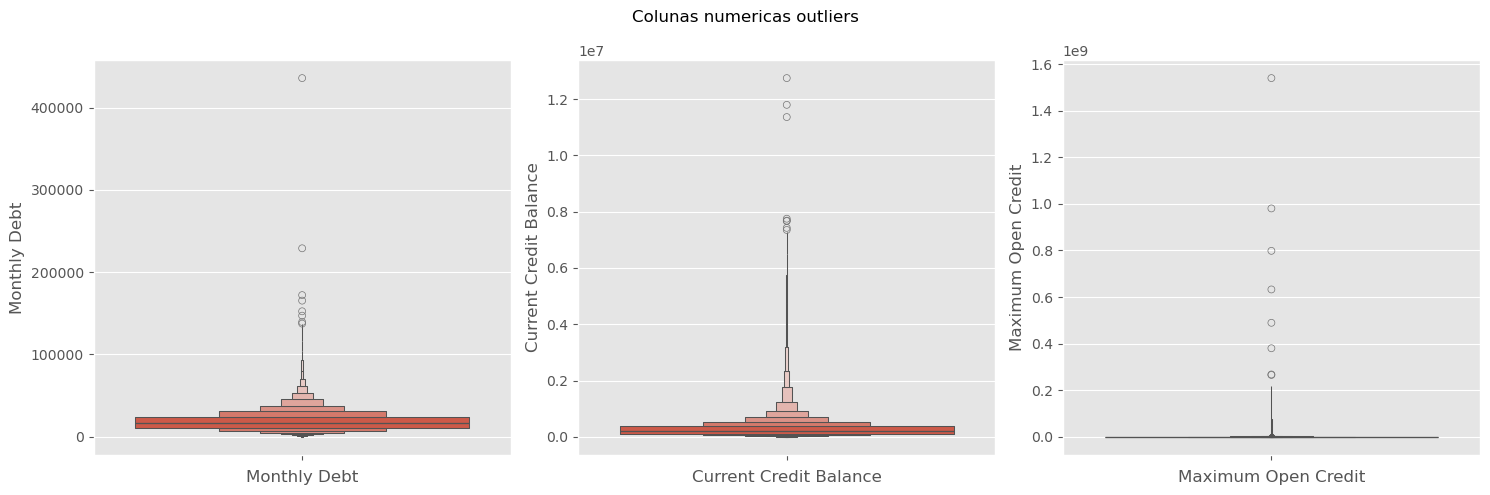

In [35]:
utilGraficos.analiseUnivariadaBoxPlot(train_df, ["Monthly Debt", "Current Credit Balance", "Maximum Open Credit"])

Essas três variáveis apresentam outliers bastante significativos que podem impactar negativamente o desempenho do modelo, principalmente ao influenciar medidas de tendência central e dispersão. Portanto, será necessário aplicar técnicas de tratamento (como Winsorization, remoção ou transformação logarítmica) para reduzir o efeito desses valores extremos e manter a robustez da análise.

In [36]:
train_df = utilTratamento.aplicarWinsorizacao(train_df, ["Monthly Debt", "Current Credit Balance", "Maximum Open Credit"])
test_df = utilTratamento.aplicarWinsorizacao(test_df, ["Monthly Debt", "Current Credit Balance", "Maximum Open Credit"])

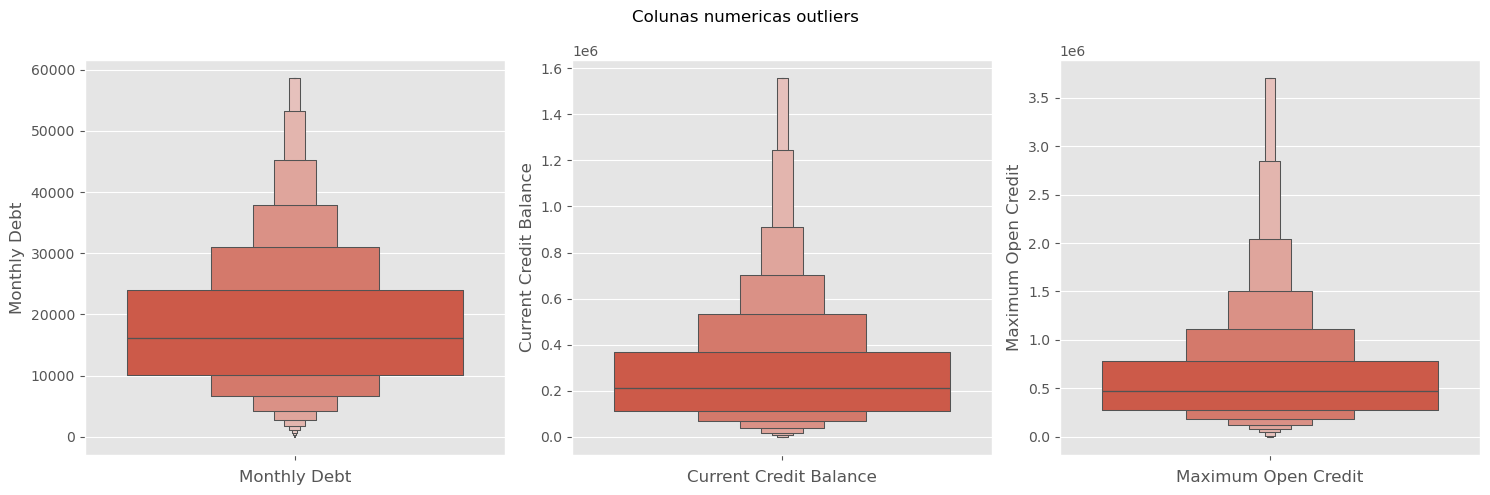

In [37]:
utilGraficos.analiseUnivariadaBoxPlot(train_df, ["Monthly Debt", "Current Credit Balance", "Maximum Open Credit"])

Com o tratamento dos outliers concluído por meio da técnica de Winsorization, as variáveis foram ajustadas e os valores extremos suavizados. Dessa forma, os dados estão mais consistentes e preparados, permitindo prosseguir com a análise exploratória e modelagem sem risco de distorções significativas.

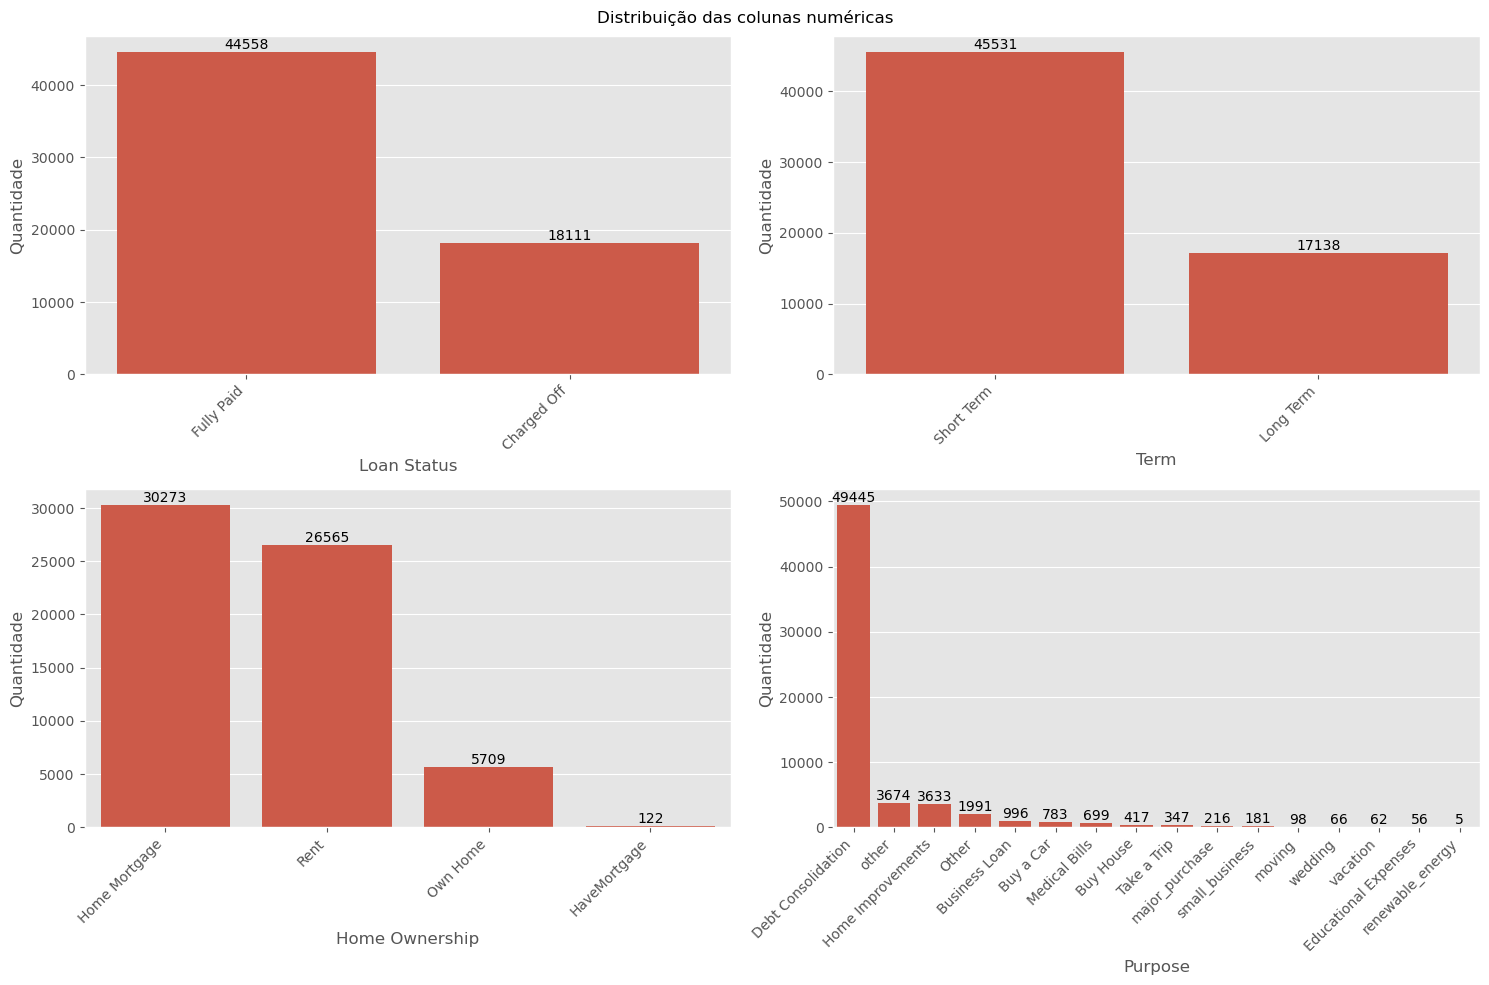

In [52]:
utilGraficos.analiseUnivariada(train_df, "object")



### Análises

1. **Status de Empréstimos**

   * Observa-se que há uma quantidade significativamente maior de clientes que **pagaram** seus empréstimos em comparação com os que **não pagaram**.
   * Esse comportamento é esperado em cenários de crédito, já que instituições financeiras normalmente aprovam clientes com maior probabilidade de pagamento.
   * Esse desbalanceamento nas classes indica que a **acurácia não é a métrica mais adequada** para avaliar o desempenho de um modelo preditivo, sendo preferível utilizar métricas como **Precisão, Recall, F1-Score ou AUC-ROC**.

2. **Term (Prazo do Empréstimo)**

   * A variável mostra predominância de empréstimos com **short term** em relação a **long term**.
   * Isso sugere que os clientes preferem empréstimos de **curto prazo**, possivelmente para evitar pagamento de juros elevados ou por restrições de aprovação.
   * Do ponto de vista da instituição financeira, prazos menores reduzem riscos de inadimplência ao encurtar o tempo de exposição do crédito.

3. **Home Ownership (Propriedade da Casa)**

   * A maioria dos clientes está distribuída principalmente entre **"Home Mortgage"** e **"Rent"**.
   * Isso mostra que grande parte dos solicitantes não possuem casa própria quitada, o que pode influenciar diretamente no risco de crédito, já que o patrimônio do cliente é menor.
   * Esse fator é relevante para análise de risco, visto que clientes com imóvel próprio quitado geralmente representam menor risco para a instituição.

4. **Purpose (Finalidade do Empréstimo)**

   * Nota-se que a finalidade mais frequente é **Debt Consolidation** (consolidação de dívidas).
   * Isso indica que muitos clientes buscam empréstimos para **reunir e refinanciar dívidas anteriores**, possivelmente visando melhores condições de pagamento ou taxas de juros mais baixas.
   * Esse perfil sugere um público que já apresenta histórico de endividamento, podendo influenciar no risco de inadimplência.


In [39]:
porenctagemTotalInadiplenciaVariaveisCategoricas("Term")

NameError: name 'porenctagemTotalInadiplenciaVariaveisCategoricas' is not defined

Após a análise da tabela, observou-se que 32% dos empréstimos de longo prazo (Long Term) resultaram em inadimplência, configurando-se como a categoria com maior incidência desse problema. Em contrapartida, os empréstimos de curto prazo (Short Term) apresentaram apenas 22% de inadimplência em relação ao total de empréstimos dessa categoria.

Esse resultado pode indicar que empréstimos de longo prazo estão associados a um maior risco de inadimplência. Para aprofundar essa análise, será investigado se os clientes com empréstimos de longo prazo possuem, em média, um Credit Score mais elevado, já que, conforme observado anteriormente, indivíduos com Credit Score mais alto na base analisada tendem a apresentar maior propensão à inadimplência.


In [ ]:
dfAnaliseExploratoria[["Credit Score", "Term"]].groupby("Term").mean().reset_index()

,Term,Credit Score
0,Long Term,1246.182767
1,Short Term,1107.433194


Analisando a tabela acima, confirma-se a hipótese de que empréstimos de longo prazo (**Long Term**) apresentam maior inadimplência. Observa-se que os clientes com empréstimos de longo prazo possuem, de fato, uma **média de Credit Score** mais elevada em comparação aos clientes de curto prazo (**Short Term**).

Esse comportamento sugere que pessoas com **Credit Score** mais alto são mais propensas a contratar empréstimos de longo prazo, possivelmente devido à sua maior capacidade de obter crédito. No entanto, essa mesma capacidade pode levá-las a assumir dívidas maiores, que podem se tornar mais difíceis de gerenciar, resultando em uma maior probabilidade de inadimplência. Assim, a análise confirma uma relação entre o tipo de empréstimo, o **Credit Score** e a inadimplência.


In [ ]:
porenctagemTotalInadiplenciaVariaveisCategoricas("Purpose")

,Purpose,Loan Status,Total,porcentagem
8,small_business,119,257,46.303502
15,renewable_energy,4,10,40.000000
11,moving,43,130,33.076923
4,Business Loan,478,1451,32.942798
12,vacation,29,94,30.851064
5,Medical Bills,278,996,27.911647
10,major_purchase,82,307,26.710098
1,other,1426,5409,26.363468
0,Debt Consolidation,17918,69506,25.779069
13,wedding,23,95,24.210526


Após a análise da tabela acima, observa-se que o maior índice de inadimplência proporcional está relacionado à categoria "small\_business", onde 46,30% dos empréstimos resultaram em inadimplência. Em seguida, destacam-se "renewable\_energy" com 40,00% e "moving" com 33,08%. Essas categorias apresentam percentuais significativamente maiores em comparação às categorias mais comuns, como "Debt Consolidation" (25,78%) e "Home Improvements" (22,70%).

Esses resultados sugerem que empréstimos para finalidades mais específicas, como pequenos negócios e mudanças, podem estar associados a maiores riscos de inadimplência. Por outro lado, categorias com maior volume de empréstimos, como "Debt Consolidation", apresentam proporções de inadimplência menores, embora em números absolutos ainda sejam expressivas devido à alta quantidade de empréstimos concedidos. Então para analisar qual deles tem o maior risco para a empresa, irei analisar a média dos emprestimos por cada proposito e irei ver quais deles dão mais prejuíso para a empresa


In [ ]:
dfAnaliseExploratoria[dfAnaliseExploratoria["Loan Status"] == 1][["Current Loan Amount", "Purpose"]].groupby("Purpose").mean().sort_values("Current Loan Amount", ascending = False)

,Current Loan Amount
Purpose,
small_business,375189.478992
Business Loan,365262.410042
Debt Consolidation,338395.617703
Home Improvements,334509.224420
Buy House,327762.757143
Other,260045.720000
major_purchase,258858.975610
other,227350.175316
wedding,226423.043478


### Análise Final: Riscos e Impactos em Categorias de Empréstimos

A análise realizada destaca a necessidade de atenção especial à categoria **Debt Consolidation**, que se mostra como a mais crítica para a empresa em termos de riscos e impactos financeiros. Apesar de os empréstimos para **small\_business** apresentarem um percentual maior de inadimplência, o número absoluto de casos em **Debt Consolidation** é muito superior.

**Principais Observações**:

1. **Quantidade de casos de inadimplência**:

   * **Debt Consolidation** registra um número muito maior de ocorrências de inadimplência em comparação com **small\_business**, o que amplifica seu impacto financeiro.

2. **Média dos valores dos empréstimos inadimplentes**:

   * Embora os valores médios dos empréstimos inadimplentes sejam semelhantes entre as duas categorias, o alto volume de inadimplências em **Debt Consolidation** resulta em um prejuízo acumulado significativamente maior.

3. **Categoria mais comum entre os empréstimos**:

   * **Debt Consolidation** é a categoria mais presente nos registros da empresa, representando uma parte substancial dos empréstimos concedidos. Isso a torna particularmente crítica, pois combina alta frequência com um dos valores médios de inadimplência mais elevados.

4. **Impacto acumulado e importância estratégica**:

   * Por ser a categoria mais recorrente e apresentar valores médios altos, qualquer variação na taxa de inadimplência em **Debt Consolidation** tem um impacto desproporcional no desempenho financeiro da empresa.

**Conclusão**:
A categoria **Debt Consolidation** deve ser o principal foco da empresa, não apenas devido ao seu impacto absoluto em termos de prejuízos, mas também porque é a mais comum entre os empréstimos concedidos. Desenvolver estratégias para mitigar os riscos nessa categoria pode trazer melhorias substanciais nos resultados da empresa.



Agora, irei analisar a ultima coluna categorica, a coluna Home Ownership(Status do proprietário em relação à moradia e pode ser usada para analisar como a posse de um imóvel está associada a diferentes variáveis)

In [ ]:
porenctagemTotalInadiplenciaVariaveisCategoricas("Home Ownership")

,Home Ownership,Loan Status,Total,porcentagem
0,Rent,10596,37493,28.261275
2,Own Home,2102,8148,25.797742
1,Home Mortgage,9910,42690,23.213867
3,HaveMortgage,31,185,16.756757


In [ ]:
dfAnaliseExploratoria[dfAnaliseExploratoria["Loan Status"] == 1][["Current Loan Amount", "Home Ownership"]].groupby("Home Ownership").mean().sort_values("Current Loan Amount", ascending = False)

,Current Loan Amount
Home Ownership,
Home Mortgage,369814.856307
Own Home,306669.774500
Rent,287266.777274
HaveMortgage,120977.290323


A análise dos dados mostra que as categorias **"Rent"** (Aluguel) e **"Home Mortgage"** (Hipoteca Residencial) são as principais áreas que a empresa precisa focar para reduzir a inadimplência. A categoria **"Rent"** apresenta a maior proporção de casos inadimplentes, representando **28,26%** do total de empréstimos concedidos nessa categoria, com uma média de valor de empréstimos inadimplentes em torno de **R\$ 287 mil**. Isso indica que, apesar do valor médio ser menor, a frequência elevada de inadimplência gera um impacto financeiro significativo.

Por sua vez, a categoria **"Home Mortgage"** apresenta uma proporção menor de inadimplência, com **23,21%**, mas possui a maior média de valor dos empréstimos inadimplentes, cerca de **R\$ 370 mil**, o que também representa um grande prejuízo financeiro para a empresa.

Portanto, ambas as categorias — **"Rent"**, por sua alta frequência de inadimplência, e **"Home Mortgage"**, pelo alto valor médio dos empréstimos inadimplentes — representam riscos financeiros importantes. A empresa deve desenvolver estratégias específicas para essas duas categorias, visando mitigar os prejuízos e melhorar a gestão de risco no portfólio de empréstimos.



Agora para finalizar a parte de tratamento/análise dos dados, irei salvar a base de dados com todos os ajustes para começar a parte criação do modelo!

In [ ]:
dfAnaliseExploratoria.to_csv("../Dados/Base de dados empréstimo tratada.csv")